# Triagem assistida por dupla IA e Cohen's Kappa
## Revisão bibliométrica — Buscas A e B

Este notebook implementa a **Etapa 1 de triagem** (título e resumo) do levantamento bibliométrico descrito no Plano Metodológico v2, seguindo:

- **Revisão de escopo** (scoping review), metodologia JBI, reportada conforme PRISMA-ScR;
- **Triagem assistida por modelos de linguagem** (LLM-Assisted Screening), com dois revisores-IA independentes;
- **Aferição de concordância** via coeficiente Cohen's Kappa (COHEN, 1960) entre os dois revisores-IA;
- **Preparação da fila de revisão humana** conforme protocolo da Seção 12.5 do plano.

### Objetos de busca

| Busca | Objeto | N (pós-deduplicação) |
|-------|--------|----------------------|
| **A** | Enforcement fiscal, cobrança, execução e litígio tributário + comportamento do contribuinte | 990 |
| **B** | Devedor contumaz / wilful default / inadimplemento deliberado | 31 |

### Fluxo metodológico

```mermaid
flowchart TD
    corpus[Corpus deduplicado CSV] --> eda[EDA descritivo]
    eda --> pilot[Calibracao piloto 20 registros]
    pilot --> ia1[Revisor-IA 1 Sonnet 5]
    pilot --> ia2[Revisor-IA 2 Sonnet 5]
    ia1 --> kappa[Cohen Kappa IA-IA]
    ia2 --> kappa
    kappa --> fila[Fila revisao humana]
    fila --> xlsx[BuscaX_Triagem_DuplaIA.xlsx]
```

> **Nota metodológica — dupla triagem com Claude Sonnet 5**
>
> O Plano Metodológico v2 (Quadro 5) prevê revisor-IA 1 em Claude e revisor-IA 2 em GPT. Esta implementação adota **duas passagens independentes** de `claude-sonnet-5` (preço introdutório até 31/08/2026). O κ IA-IA mede **estabilidade/consistência** entre duas classificações do mesmo modelo, não independência entre fornecedores. O **índice principal de confiabilidade** permanece o κ entre os dois revisores humanos (camada 2).
>
> **Nota técnica — pydantic-ai + prompt caching**
>
> Toda interação com LLM neste repositório passa por **[pydantic-ai](https://ai.pydantic.dev/)** (`Agent` + `output_type` estruturado), com `anthropic_cache_instructions=True` para cachear o system prompt. Ver `docs/PROJECT_SOURCE_OF_TRUTH.md` §3.4.


## 1. Setup e configuração

In [16]:
from __future__ import annotations

import json
import os
import random
import sys
import time
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from dotenv import load_dotenv
from sklearn.metrics import cohen_kappa_score, confusion_matrix

load_dotenv()

ARTICLE_CANDIDATES = [
    Path("projects/litigancia/notebooks/articles/revisao-bibliometrica-2026"),
    Path("notebooks/articles/revisao-bibliometrica-2026"),  # legacy A layout
]
ARTICLE_ROOT = next((c for c in ARTICLE_CANDIDATES if (c / "artifacts").exists()), None)
if ARTICLE_ROOT is None:
    ARTICLE_ROOT = Path.cwd()
    if ARTICLE_ROOT.name == "revisao-bibliometrica-2026":
        pass
    elif (ARTICLE_ROOT / "projects/litigancia/notebooks/articles/revisao-bibliometrica-2026/artifacts").exists():
        ARTICLE_ROOT = ARTICLE_ROOT / "projects/litigancia/notebooks/articles/revisao-bibliometrica-2026"
    elif (ARTICLE_ROOT / "notebooks/articles/revisao-bibliometrica-2026/artifacts").exists():
        ARTICLE_ROOT = ARTICLE_ROOT / "notebooks/articles/revisao-bibliometrica-2026"
    elif (ARTICLE_ROOT.parent / "artifacts").exists() and ARTICLE_ROOT.parent.name == "revisao-bibliometrica-2026":
        ARTICLE_ROOT = ARTICLE_ROOT.parent

if (ARTICLE_ROOT / "artifacts").exists():
    # articles → notebooks → litigancia → projects → mono
    MONO_ROOT = ARTICLE_ROOT.parents[4] if "projects" in ARTICLE_ROOT.parts else ARTICLE_ROOT.parents[2]
    PIPELINE_ROOT = MONO_ROOT / "pipelines/litigancia"
    REPO_ROOT = MONO_ROOT
else:
    REPO_ROOT = Path.cwd()
    PIPELINE_ROOT = REPO_ROOT / "pipelines/litigancia"

for candidate in (PIPELINE_ROOT / "src", PIPELINE_ROOT, REPO_ROOT):
    if candidate.exists() and str(candidate) not in sys.path:
        sys.path.insert(0, str(candidate))
        break

from utils.bibliometric_screening import (
    CRITERIA_BY_BUSCA,
    DECISION_LABELS,
    SYSTEM_PROMPT_A,
    SYSTEM_PROMPT_B,
    archive_legacy_artifacts,
    build_screening_agent,
    cache_path,
    load_cache,
    model_slug,
    run_screening,
)

DATA_ROOT = PIPELINE_ROOT / ".tmp/Revisao Bibliométrica/Dados"
if not DATA_ROOT.exists():
    # fallback: archive A still holds the bibliometric inputs
    DATA_ROOT = Path("/Users/etorebraga/Code/habitual-tax-debtor-research/.tmp/Revisao Bibliométrica/Dados")
ARTIFACTS_DIR = ARTICLE_ROOT / "artifacts"
CACHE_DIR = ARTIFACTS_DIR / "cache"
PROGRESS_DIR = ARTIFACTS_DIR / "progress"
for directory in (CACHE_DIR, PROGRESS_DIR):
    directory.mkdir(parents=True, exist_ok=True)

archived = archive_legacy_artifacts(ARTIFACTS_DIR)
if archived:
    print(f"Cache v1 arquivado ({len(archived)} arquivos) em artifacts/archive_pre_v2/")

PILOT_CSV_PATH = ARTIFACTS_DIR / "Piloto_Calibracao_BuscaA.csv"
HUMAN_REVIEW_CSV = {
    "A": ARTIFACTS_DIR / "BuscaA_Revisao_Humana.csv",
    "B": ARTIFACTS_DIR / "BuscaB_Revisao_Humana.csv",
}

BUSCA_A_PATH = DATA_ROOT / "Busca A/com_filtros/BuscaA_Unificado_Deduplicado.csv"
BUSCA_B_PATH = DATA_ROOT / "Busca B/com_filtros/BuscaB_Unificado_Deduplicado.csv"

PROVIDER = "anthropic"
MODEL_IA1 = "claude-sonnet-5"
MODEL_IA2 = "claude-sonnet-5"
LEGACY_MODEL = "claude-sonnet-4-6"  # ia1 parcial já pago; migrado via merge_legacy_cache
PILOT_SAMPLE_SIZE = 20
EXCLUDE_SAMPLE_RATE = 0.20
RANDOM_SEED = 42
MAX_CONCURRENT_REQUESTS = 10
PILOT_GATE_REQUIRED = True
PILOT_APPROVED = True

# "pilot" = calibração (20 registros, IA1) | "full" = triagem completa (ia1 + ia2 × 1.021 registros)
RUN_MODE = "full"

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 120

print(f"Repositório: {REPO_ROOT}")
print(f"Busca A: {BUSCA_A_PATH.exists()} | Busca B: {BUSCA_B_PATH.exists()}")
print(f"Modelos: IA1={MODEL_IA1} | IA2={MODEL_IA2} (pydantic-ai / {PROVIDER})")
print(f"RUN_MODE: {RUN_MODE}")
print(f"Concorrência pydantic-ai: {MAX_CONCURRENT_REQUESTS}")
print(f"PILOT_GATE_REQUIRED: {PILOT_GATE_REQUIRED} | PILOT_APPROVED: {PILOT_APPROVED}")


Repositório: /Users/etorebraga/Code/habitual-tax-debtor-research
Busca A: True | Busca B: True
Modelos: IA1=claude-sonnet-5 | IA2=claude-sonnet-5 (pydantic-ai / anthropic)
RUN_MODE: full
Concorrência pydantic-ai: 10
PILOT_GATE_REQUIRED: True | PILOT_APPROVED: True


## 2. EDA — Análise exploratória dos corpora

Antes da triagem, caracterizamos os portfólios deduplicados: dimensão, completude, distribuição por base de origem (Scopus/WoS), tipo documental, evolução temporal, idioma, periódicos, autores, palavras-chave e instituições.



Busca A
Dimensão: 990 registros × 35 colunas


,id_seq,source,tipo_documento,autores,editores,titulo,titulo_alternativo,ano,fonte,fonte_abrev,...,notas,editora,cidade_editora,endereco_editora,issn_isbn,idioma,conferencia,referencias_citadas,afiliacao_padronizada,busca
0,1,Scopus,JOUR,"Alfaro, F. | Paredes, D. | Skidmore, M.",,The Effect of Property Assessment Reductions o...,,2025,National Tax Journal,Natl. Tax J.,...,Export Date: 12 June 2026; Cited By: 0,University of Chicago Press,,,00280283 (ISSN),English,,,,A
1,2,Scopus,JOUR,"Artič, N. | Kovač, P.",,Legal Analysis of the Tax Enforcement Systems ...,,2025,NISPAcee Journal of Public Administration and ...,NISPAcee J. Public Adm. Policy,...,Export Date: 12 June 2026; Cited By: 0,Sciendo,,,13379038 (ISSN),English,,,,A
2,3,Scopus,JOUR,"Cipollini, C.",,Crypto Staking Taxation Across Selected Countr...,,2024,Intertax,Intertax,...,Export Date: 12 June 2026; Cited By: 5; Corres...,Kluwer Law International,,,01652826 (ISSN),English,,,,A


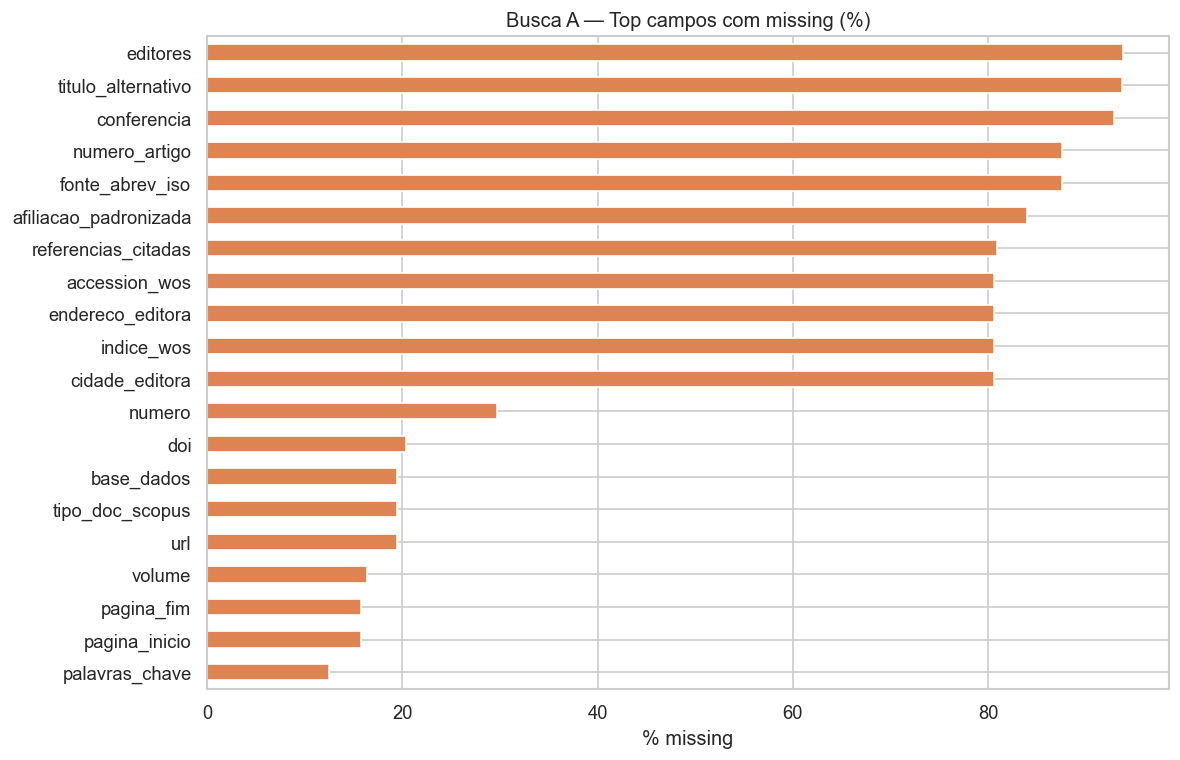

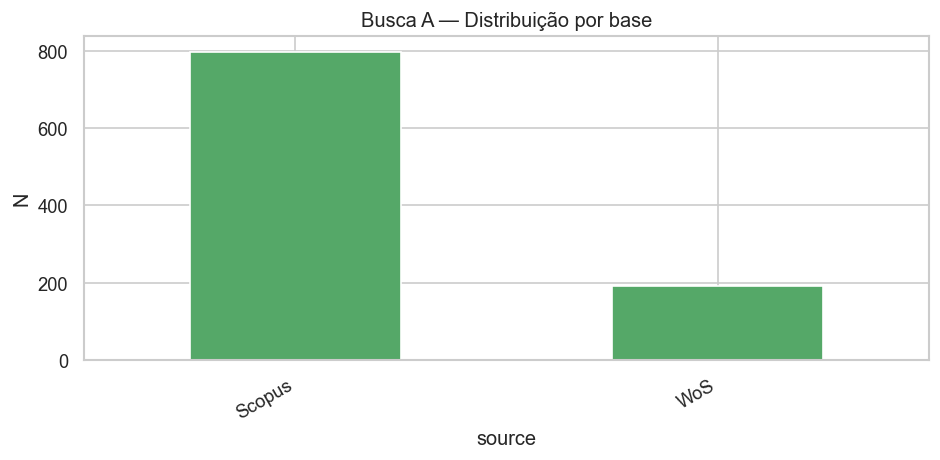

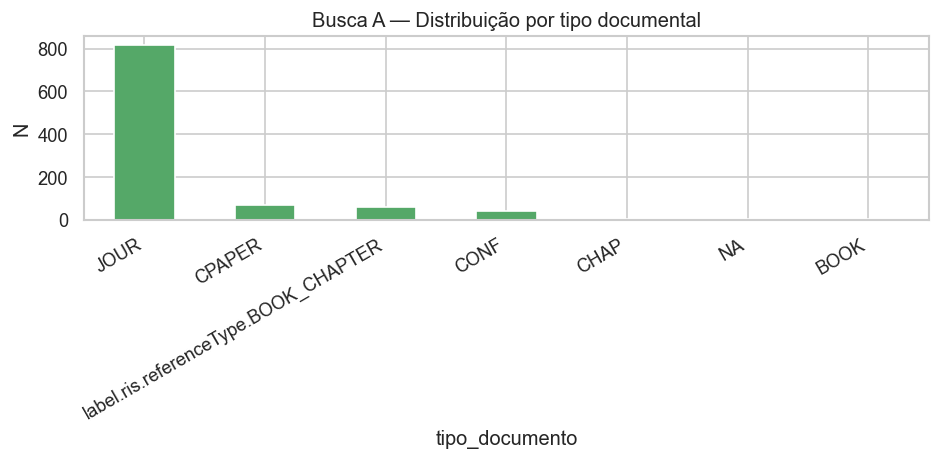

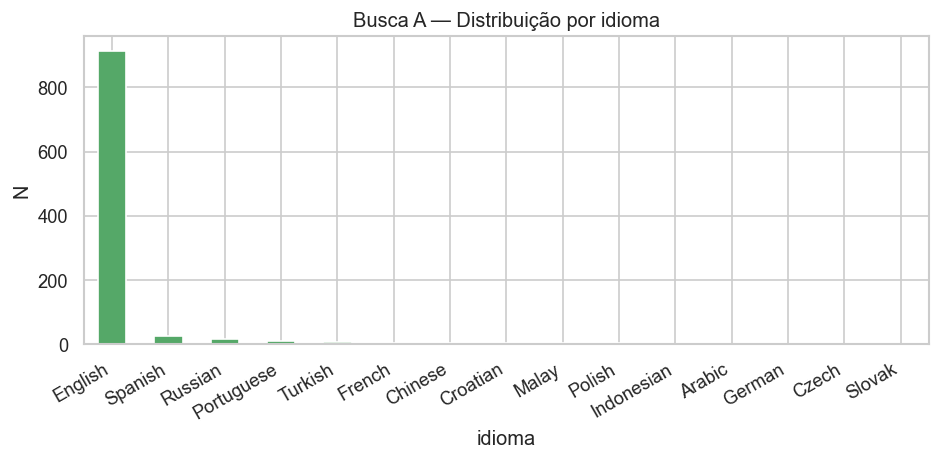

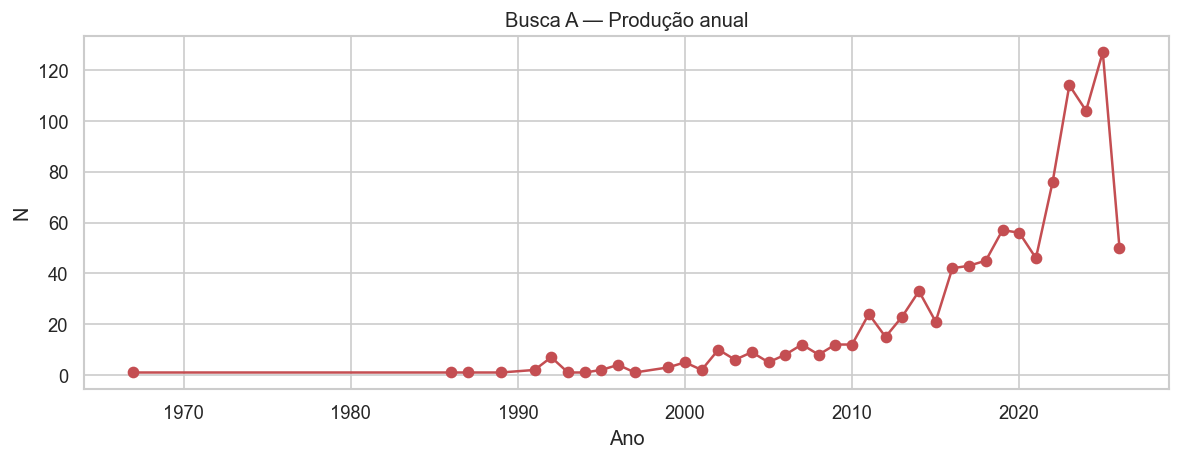

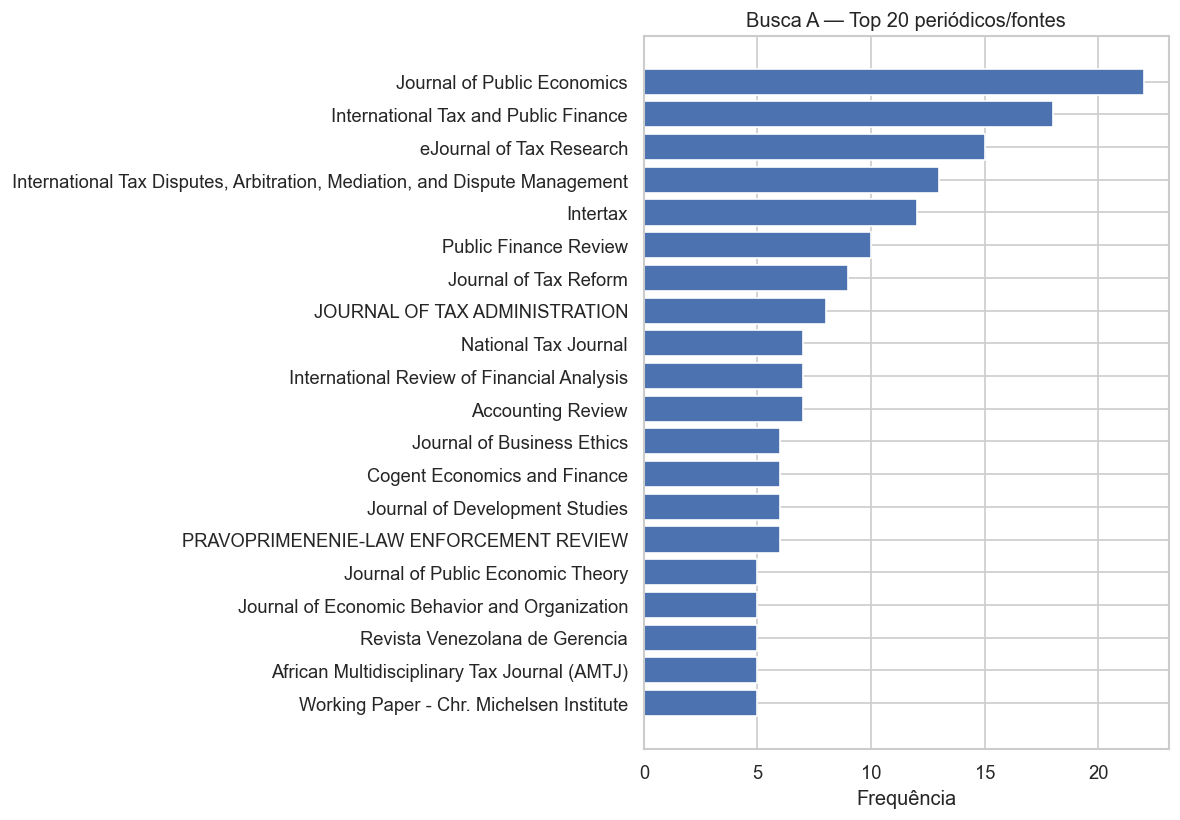

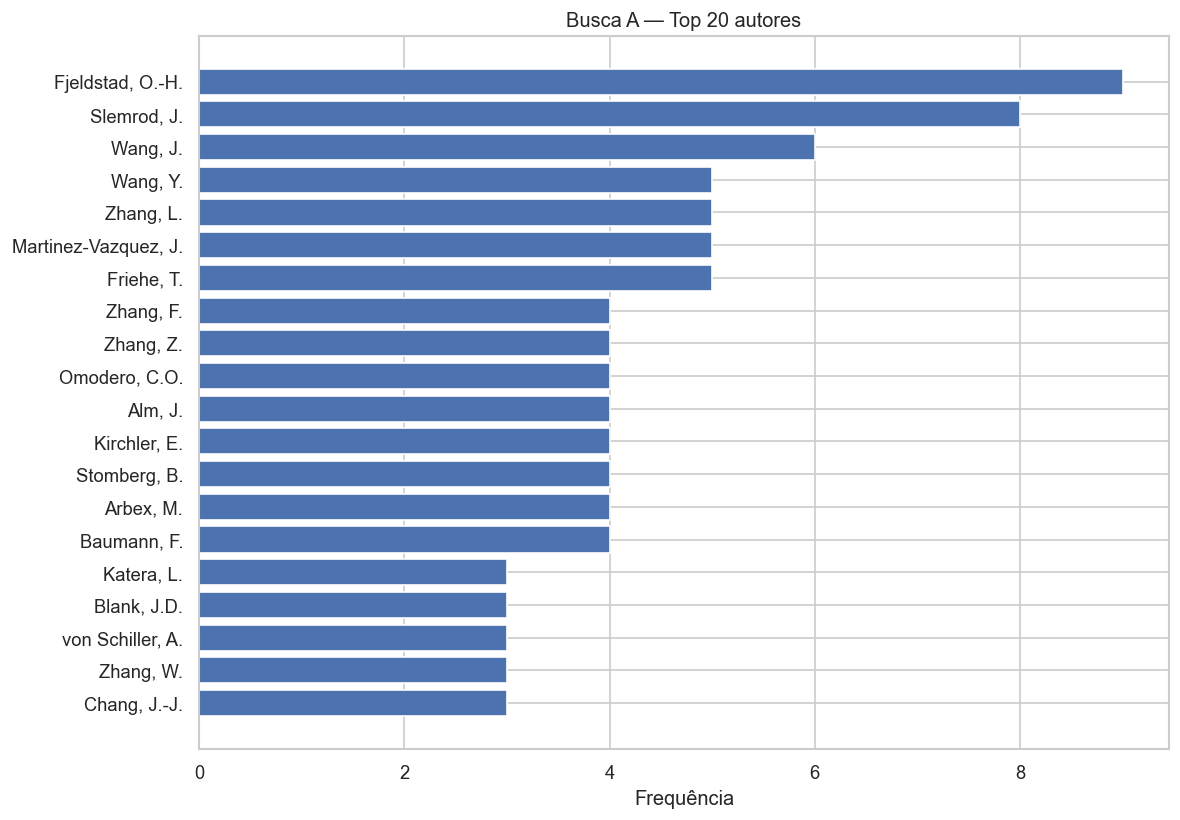

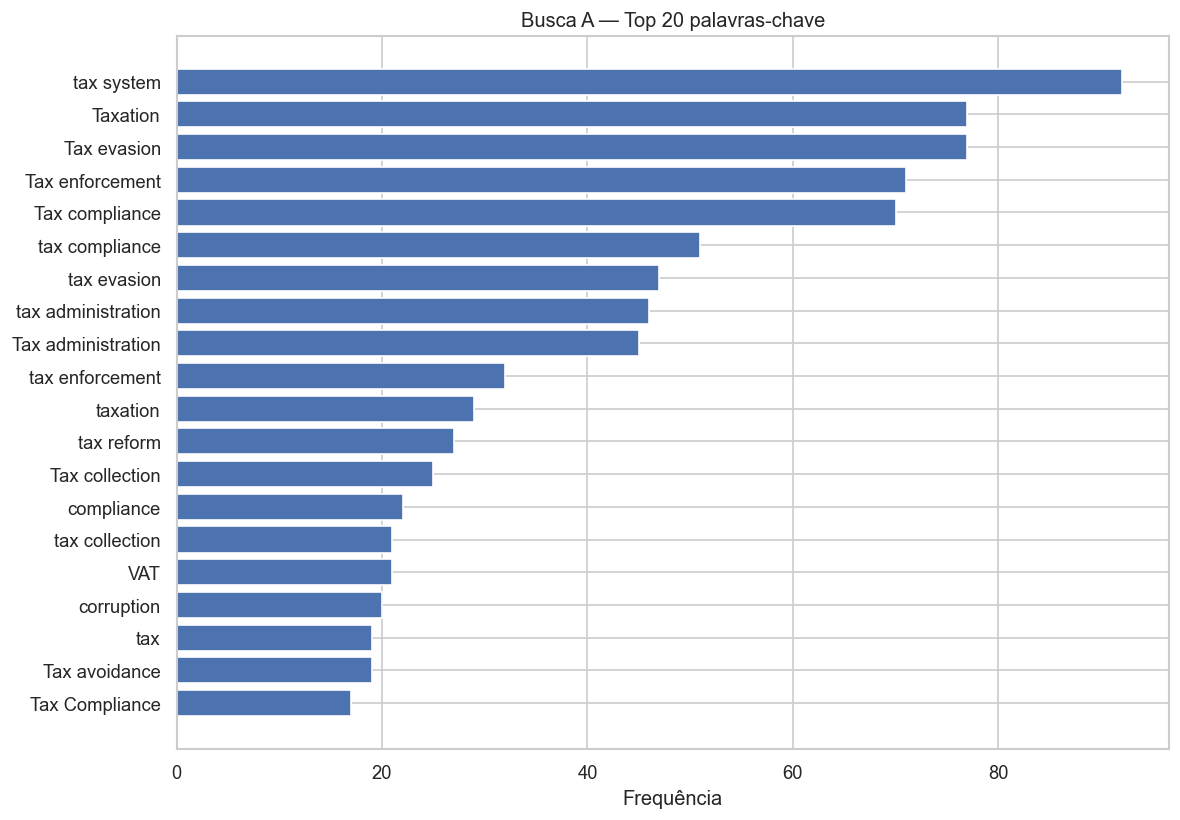

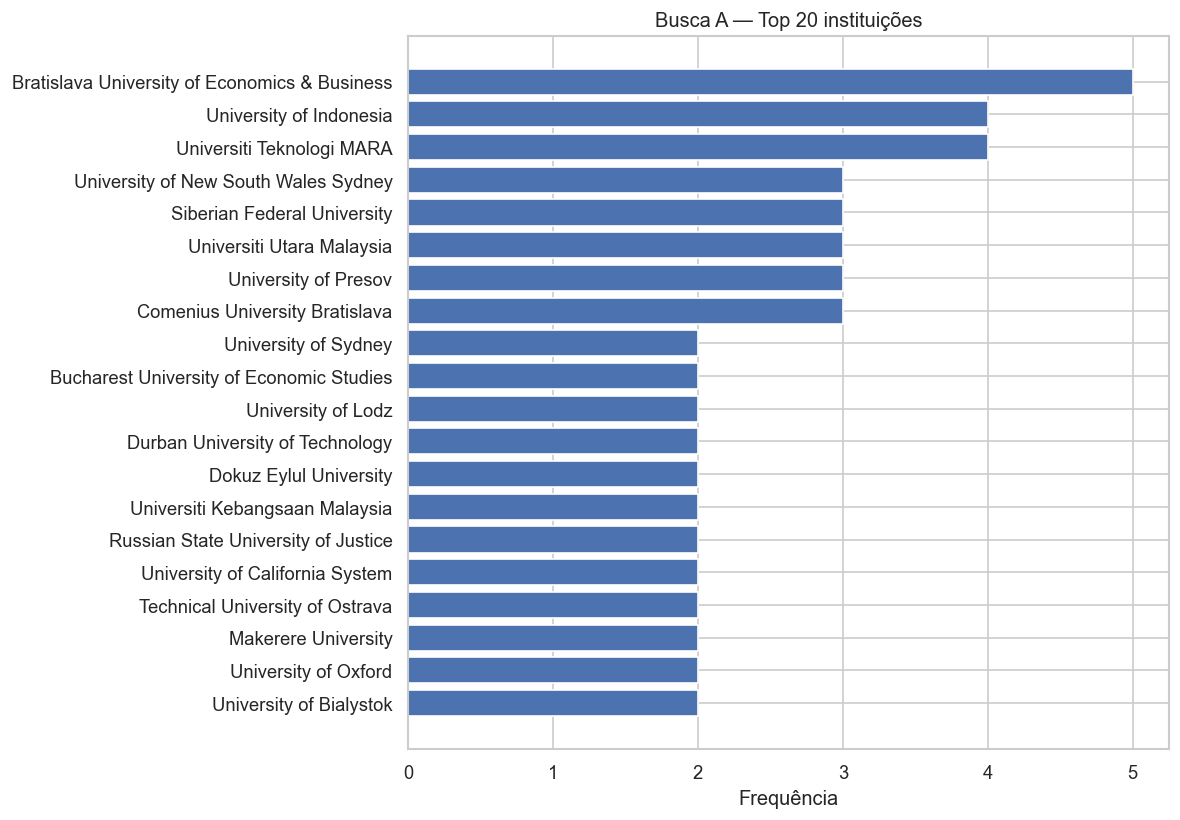


Busca B
Dimensão: 31 registros × 35 colunas


,id_seq,source,tipo_documento,autores,editores,titulo,titulo_alternativo,ano,fonte,fonte_abrev,...,notas,editora,cidade_editora,endereco_editora,issn_isbn,idioma,conferencia,referencias_citadas,afiliacao_padronizada,busca
0,1,WoS,,"Jayadev, M | Padma, N",,Wilful defaulters of Indian banks: A first cut...,,2020,IIMB MANAGEMENT REVIEW,IIMB MANAG REV,...,Times Cited in Web of Science Core Collection:...,ELSEVIER,AMSTERDAM,"RADARWEG 29, 1043 NX AMSTERDAM, NETHERLANDS",0970-3896 | 2212-4446,English,,"[Anonymous], 2016, WP16243 IMF | [Anonymous], ...",Indian Institute of Management (IIM System),B
1,2,WoS,JOUR,"Cohen, L | Seymour, T",,"Trustee exculpation-the law, the quirks and th...",,2014,TRUSTS & TRUSTEES,TRUSTS TRUSTEES,...,Times Cited in Web of Science Core Collection:...,OXFORD UNIV PRESS,OXFORD,"GREAT CLARENDON ST, OXFORD OX2 6DP, ENGLAND",1363-1780 | 1752-2110,English,,,,B
2,3,WoS,JOUR,"NUNNENKAMP, P | PICHT, H",,WILLFUL DEFAULT BY DEVELOPING-COUNTRIES IN THE...,,1989,WELTWIRTSCHAFTLICHES ARCHIV-REVIEW OF WORLD EC...,WELTWIRTSCH ARCH,...,Times Cited in Web of Science Core Collection:...,J C B MOHR,TUBINGEN,"POSTFACH 2040, W-7400 TUBINGEN, GERMANY",0043-2636,English,,"ABRASSI B, 1982, 36 CIT U BUS SCH WOR | Altman...",Indiana University System,B


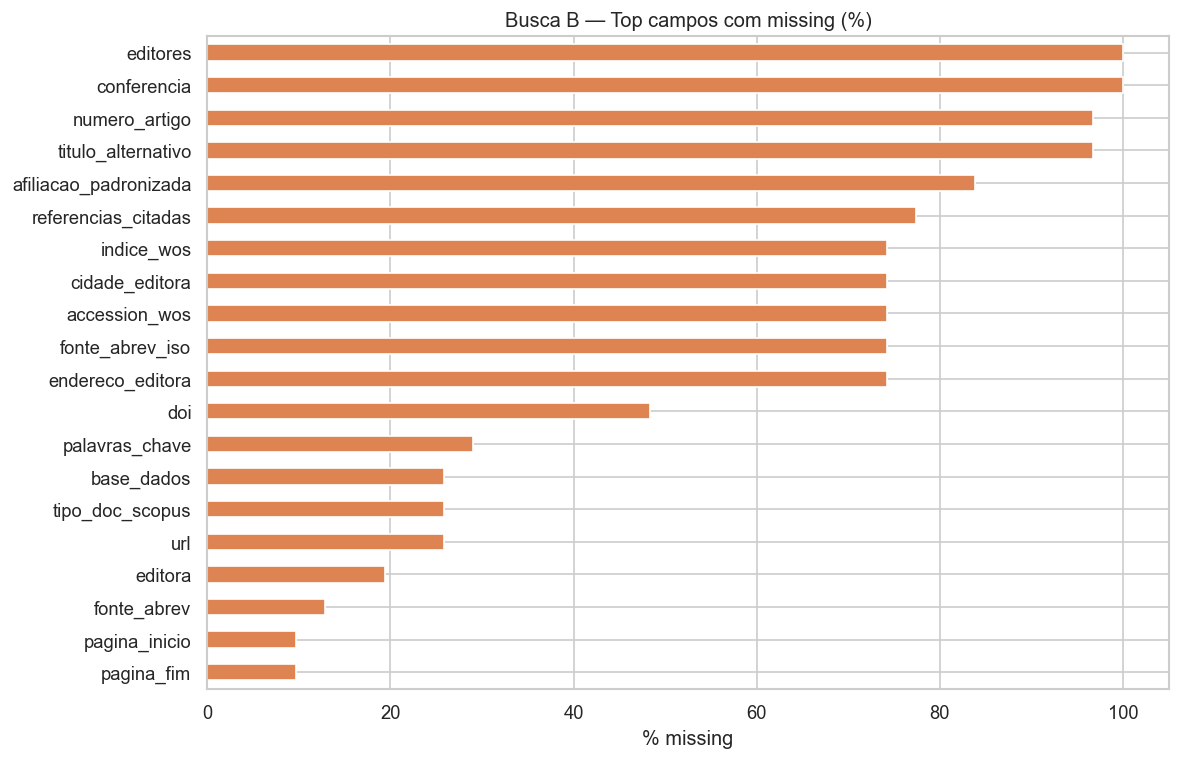

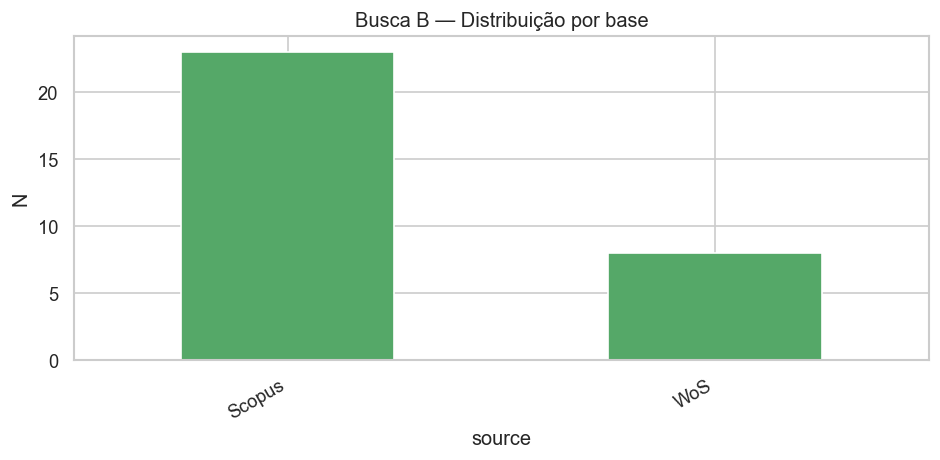

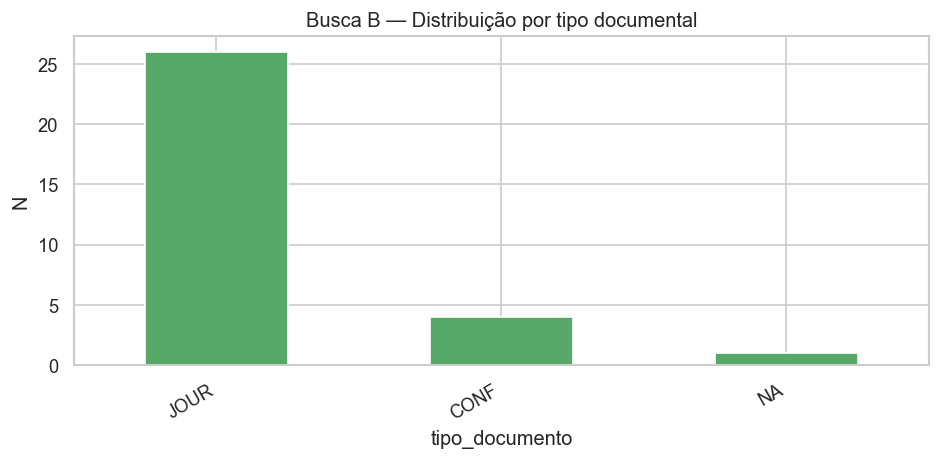

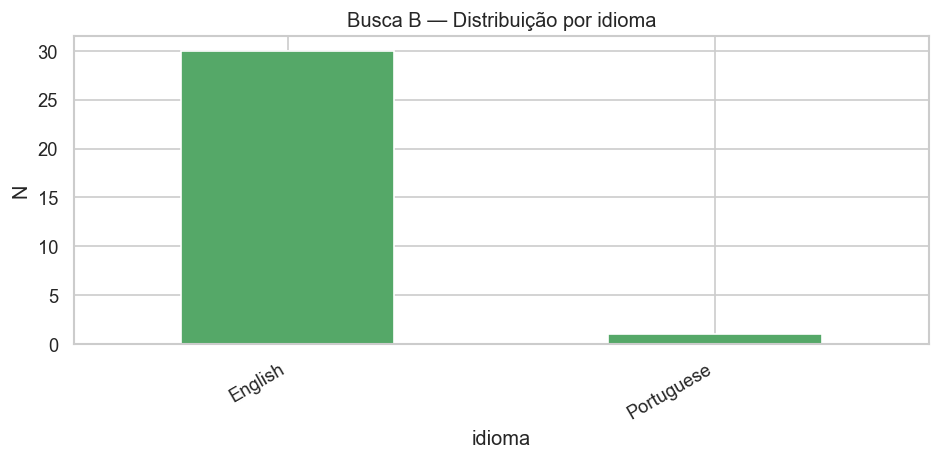

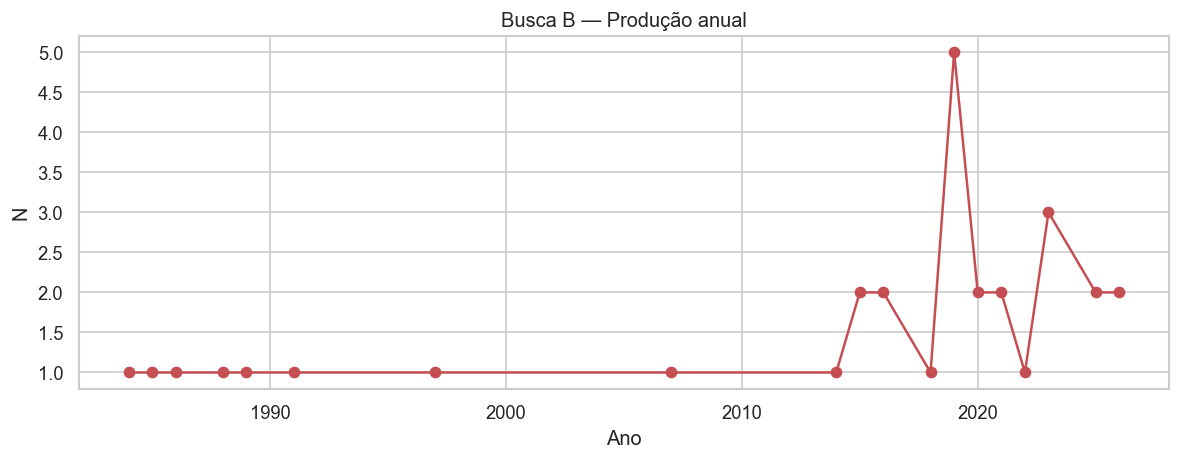

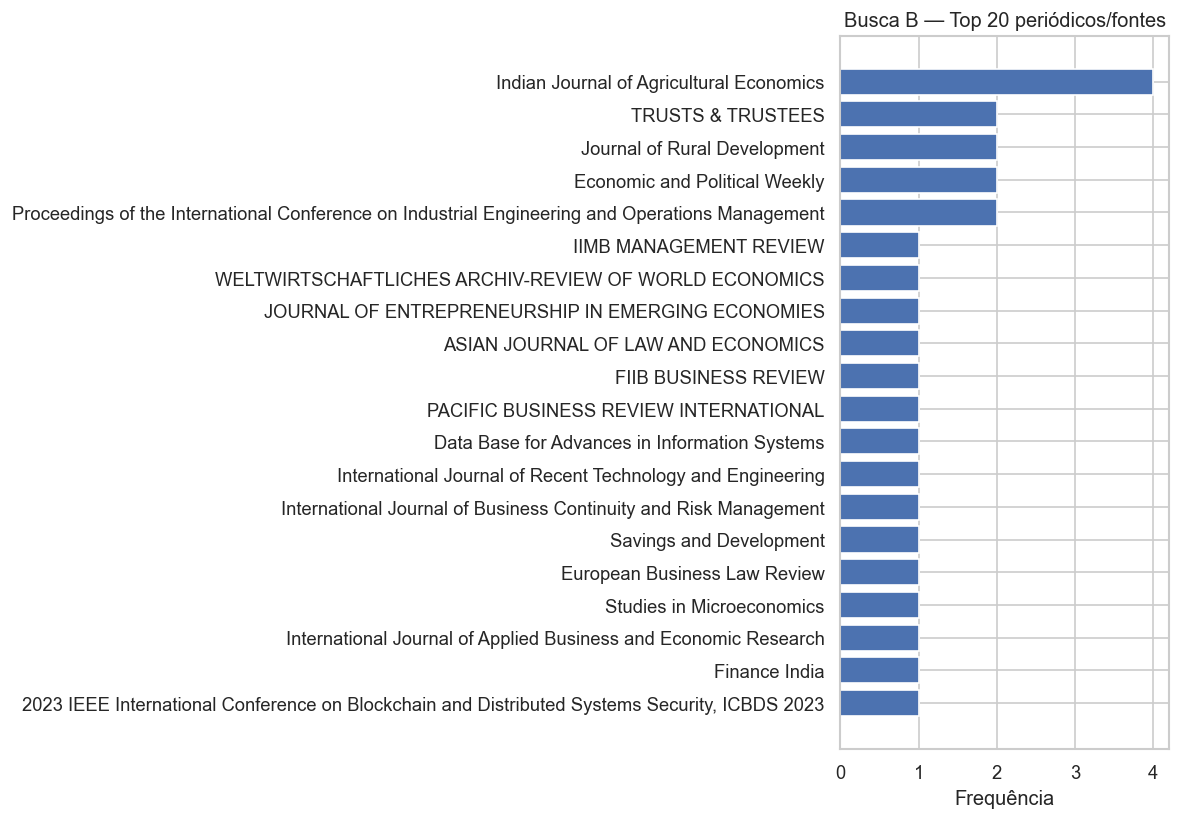

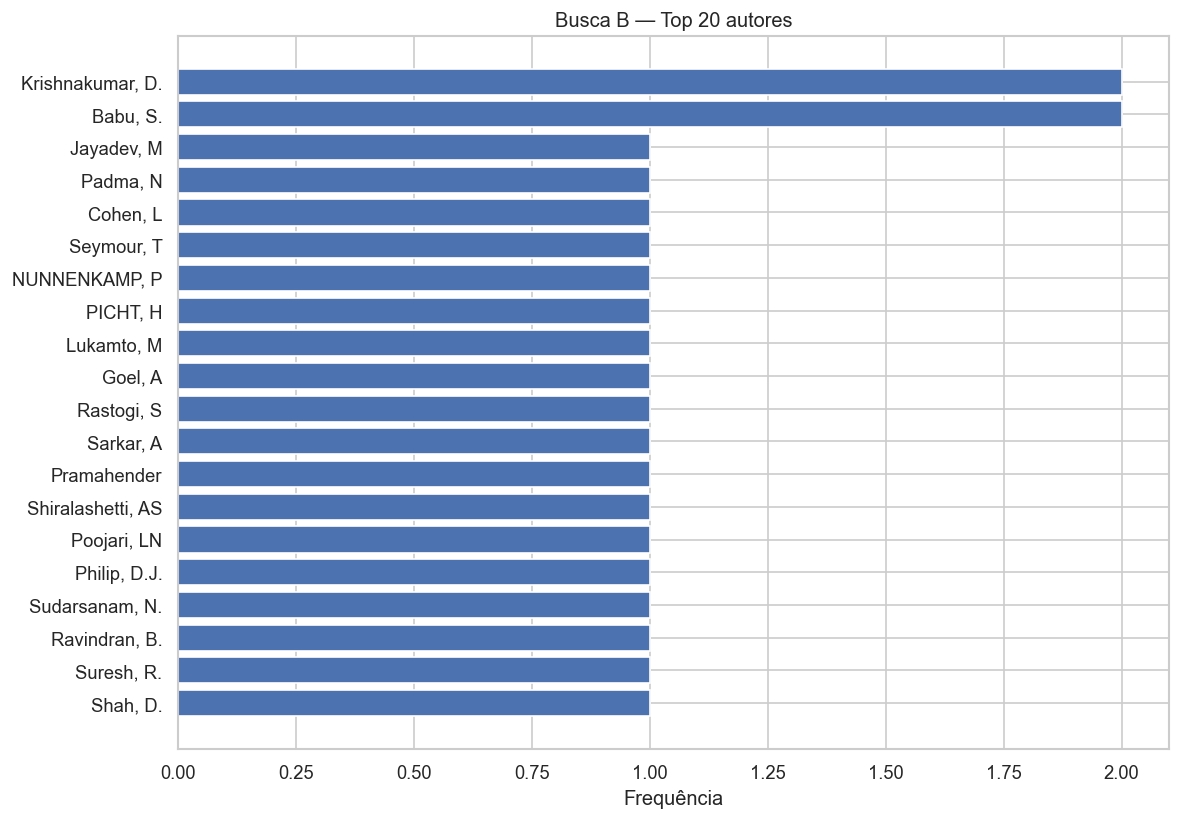

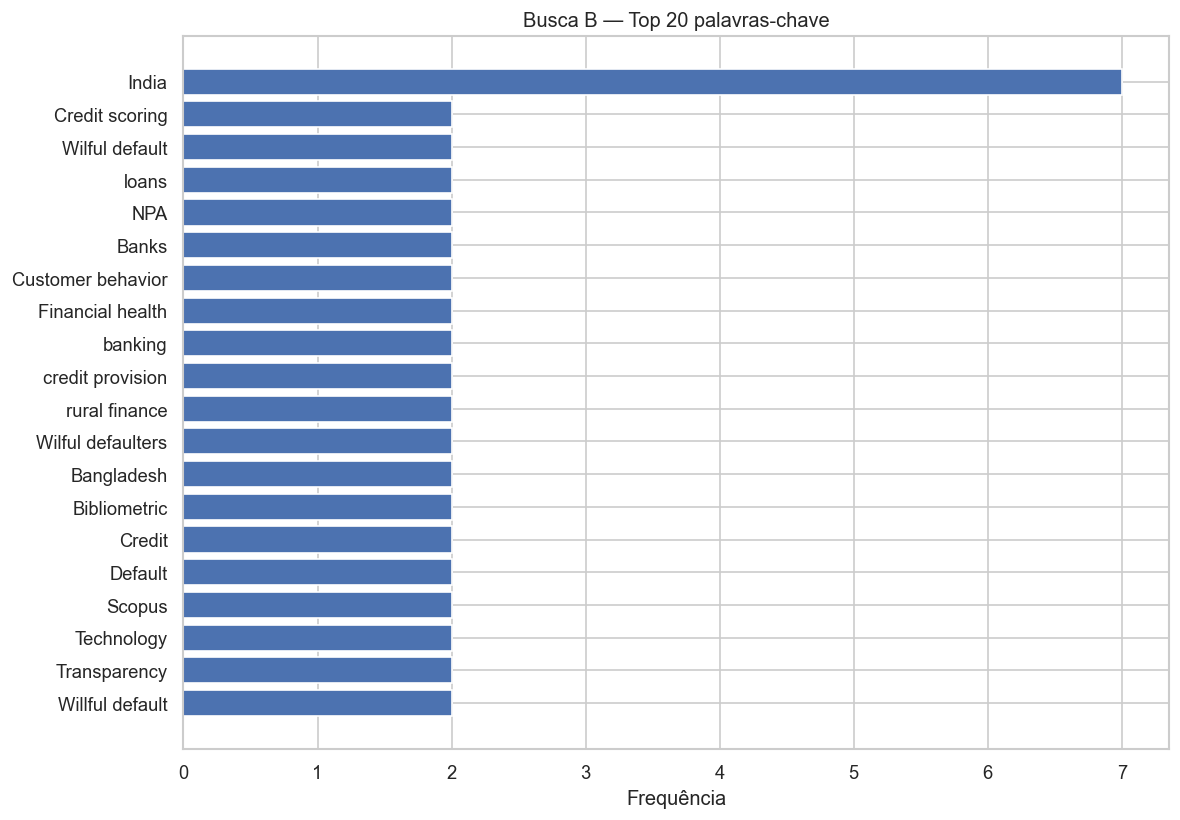

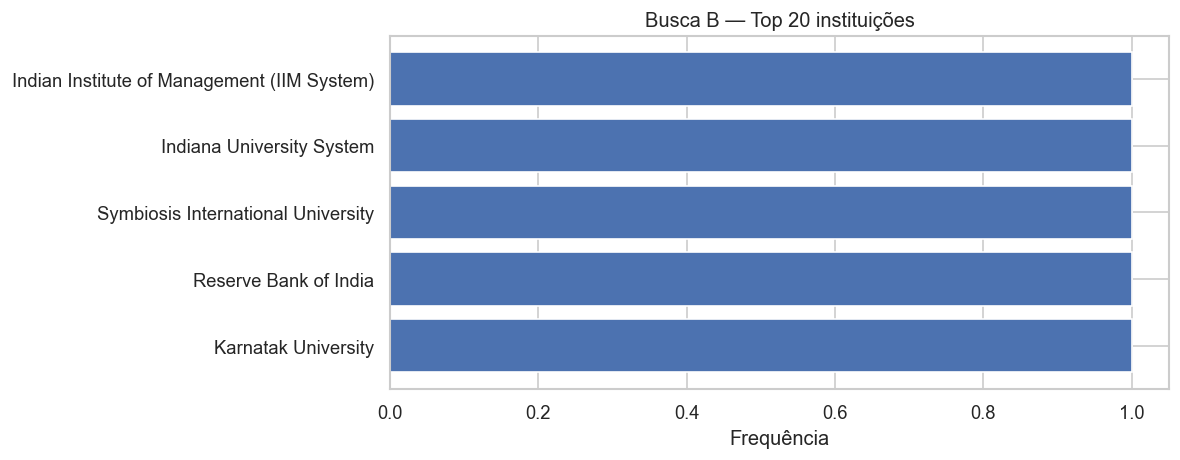


Resumo comparativo


,Busca A,Busca B
Registros,990,31
Bases distintas,2,2
Idiomas distintos,15,2


In [17]:
def load_corpus(path: Path, busca: str) -> pd.DataFrame:
    df = pd.read_csv(path, dtype=str).fillna("")
    df["busca"] = busca
    df["id_seq"] = pd.to_numeric(df["id_seq"], errors="coerce").astype("Int64")
    return df


def split_pipe_values(series: pd.Series) -> Counter:
    counter: Counter[str] = Counter()
    for raw in series.fillna(""):
        for item in str(raw).split("|"):
            token = item.strip()
            if token:
                counter[token] += 1
    return counter


def plot_top_counter(counter: Counter, title: str, top_n: int = 20) -> None:
    items = counter.most_common(top_n)
    if not items:
        print(f"Sem dados para: {title}")
        return
    labels, values = zip(*items, strict=True)
    fig, ax = plt.subplots(figsize=(10, max(4, 0.35 * len(labels))))
    ax.barh(list(reversed(labels)), list(reversed(values)), color="#4C72B0")
    ax.set_title(title)
    ax.set_xlabel("Frequência")
    plt.tight_layout()
    plt.show()


def run_eda(df: pd.DataFrame, title: str) -> None:
    print(f"\n{'=' * 80}\n{title}\n{'=' * 80}")
    print(f"Dimensão: {df.shape[0]} registros × {df.shape[1]} colunas")
    display(df.head(3))

    missing_pct = (df.replace("", np.nan).isna().mean() * 100).sort_values(ascending=False)
    missing_pct = missing_pct[missing_pct > 0]
    if not missing_pct.empty:
        fig, ax = plt.subplots(figsize=(10, max(3, 0.25 * len(missing_pct))))
        missing_pct.head(20).sort_values().plot(kind="barh", ax=ax, color="#DD8452")
        ax.set_title(f"{title} — Top campos com missing (%)")
        ax.set_xlabel("% missing")
        plt.tight_layout()
        plt.show()
    else:
        print("Nenhum missing detectado nos campos textuais.")

    for col, chart_title in [
        ("source", "Distribuição por base"),
        ("tipo_documento", "Distribuição por tipo documental"),
        ("idioma", "Distribuição por idioma"),
    ]:
        counts = df[col].replace("", "NA").value_counts()
        fig, ax = plt.subplots(figsize=(8, 4))
        counts.plot(kind="bar", ax=ax, color="#55A868")
        ax.set_title(f"{title} — {chart_title}")
        ax.set_ylabel("N")
        plt.xticks(rotation=30, ha="right")
        plt.tight_layout()
        plt.show()

    anos = pd.to_numeric(df["ano"], errors="coerce")
    yearly = anos.dropna().astype(int).value_counts().sort_index()
    fig, ax = plt.subplots(figsize=(10, 4))
    yearly.plot(kind="line", marker="o", ax=ax, color="#C44E52")
    ax.set_title(f"{title} — Produção anual")
    ax.set_xlabel("Ano")
    ax.set_ylabel("N")
    plt.tight_layout()
    plt.show()

    plot_top_counter(split_pipe_values(df["fonte"]), f"{title} — Top 20 periódicos/fontes")
    plot_top_counter(split_pipe_values(df["autores"]), f"{title} — Top 20 autores")
    plot_top_counter(split_pipe_values(df["palavras_chave"]), f"{title} — Top 20 palavras-chave")
    plot_top_counter(
        split_pipe_values(df["afiliacao_padronizada"]),
        f"{title} — Top 20 instituições",
    )


df_a = load_corpus(BUSCA_A_PATH, "A")
df_b = load_corpus(BUSCA_B_PATH, "B")

run_eda(df_a, "Busca A")
run_eda(df_b, "Busca B")

print("\nResumo comparativo")
summary = pd.DataFrame(
    {
        "Busca A": [len(df_a), df_a["source"].nunique(), df_a["idioma"].nunique()],
        "Busca B": [len(df_b), df_b["source"].nunique(), df_b["idioma"].nunique()],
    },
    index=["Registros", "Bases distintas", "Idiomas distintos"],
)
display(summary)


## 3. Engenharia de prompt e livro de códigos

Cada registro é classificado com base no **título**, **resumo** e **palavras-chave**, seguindo critérios de **exclusão binários** (EC). O fluxo decisório interrompe-se no primeiro critério satisfeito. Havendo dúvida razoável, o rótulo é `dúvida` (princípio conservador).

### Busca A — Critérios de exclusão (Etapa 1)

| Código | Critério | Exclui-se quando... |
|--------|----------|---------------------|
| EC-A1 | Fora do contexto tributário-estatal | não trata do contexto tributário-estatal ou da administração pública |
| EC-A2 | Ausência de cobrança coercitiva ou litígio | não aborda a dimensão coercitiva, executória ou contenciosa da cobrança tributária |
| EC-A3 | Ausência de comportamento do devedor | não contempla o comportamento estratégico, a conformidade ou a conduta litigiosa do contribuinte |
| EC-A4 | Idioma | não está em português, inglês ou espanhol |
| EC-A5 | Fase pré-litigiosa atitudinal isolada | limita-se à percepção atitudinal sem conexão com efetividade da cobrança/enforcement |
| EC-A6 | Nível de análise incompatível | trata enforcement/eficiência arrecadatória exclusivamente em nível macro ou cross-country |

Etapa 2 (texto completo): EC-A7 (texto não localizado), EC-A8 (duplicata/sobreposição).

### Busca B — Critérios de exclusão (Etapa 1)

| Código | Critério | Exclui-se quando... |
|--------|----------|---------------------|
| EC-B1 | Ausência de inadimplência estratégica | não aborda inadimplemento deliberado, estratégico ou contumaz |
| EC-B2 | Foco exclusivo em persecução penal | foca só em crimes financeiros sem relação com recuperação de crédito ou contencioso tributário |
| EC-B3 | Programas genéricos de conformidade ou anistia | trata só de programas/anistias sem isolar devedor reincidente ou recalcitrante |
| EC-B4 | Idioma | não está em português, inglês ou espanhol |

Etapa 2 (texto completo): EC-B5 (texto não localizado), EC-B6 (duplicata/sobreposição).

A resposta da IA deve ser JSON estrito:

```json
{"decisao": "incluir|excluir|dúvida", "criterio": "EC-A1|null", "justificativa": "..."}
```


In [10]:
def evaluate_pilot_gate(pilot_results: list[dict]) -> dict[str, object]:
    df = pd.DataFrame(pilot_results)
    incluir_com_ec = int(
        ((df["decisao"] == "incluir") & df["criterio"].notna() & (df["criterio"] != "")).sum()
    )
    inconsistencias = int(df["inconsistencia_json"].fillna(False).astype(bool).sum())
    excluir_sem_ec = int(
        ((df["decisao"] == "excluir") & (df["criterio"].isna() | (df["criterio"] == ""))).sum()
    )
    duvida_sem_ec = int(
        ((df["decisao"] == "dúvida") & (df["criterio"].isna() | (df["criterio"] == ""))).sum()
    )
    passed = incluir_com_ec == 0
    return {
        "passed": passed,
        "incluir_com_ec": incluir_com_ec,
        "inconsistencias_json": inconsistencias,
        "excluir_sem_ec": excluir_sem_ec,
        "duvida_sem_ec": duvida_sem_ec,
        "n_registros": len(df),
    }


print("Prompts v2 e guardrails carregados (src/utils/bibliometric_screening.py).")
print(f"Critérios Busca A: {sorted(CRITERIA_BY_BUSCA['A'])}")
print(f"Critérios Busca B: {sorted(CRITERIA_BY_BUSCA['B'])}")


Prompts v2 e guardrails carregados (src/utils/bibliometric_screening.py).
Critérios Busca A: ['EC-A1', 'EC-A2', 'EC-A3', 'EC-A4', 'EC-A5', 'EC-A6']
Critérios Busca B: ['EC-B1', 'EC-B2', 'EC-B3', 'EC-B4']


## 4. Triagem por dupla IA (pydantic-ai + cache idempotente)

> **Nota metodológica**
>
> Revisor-IA 1 e Revisor-IA 2: `claude-sonnet-5` (duas passagens independentes, mesmo prompt). Execução via **pydantic-ai** (`Agent` + `ScreeningDecision`) com **prompt caching** nas instruções.

Cada combinação `(busca, revisor)` grava resultados em JSONL (`artifacts/cache/`). Reexecutar o notebook **não** reinvoca a API para registros já cacheados.

### Calibração piloto (20 registros)

Antes da triagem integral, classificamos uma **amostra aleatória de 20 registros** da Busca A para:

1. **Validar o prompt** — verificar se o modelo interpreta corretamente os critérios EC-A1 a EC-A6;
2. **Detectar ambiguidades** — identificar casos-limite (EC-A5, EC-A6) antes de processar 990 registros;
3. **Estimar custo e tempo** — dimensionar a execução completa (duas passagens × 1.021 registros);
4. **Registrar reprodutibilidade** — fixar a versão final do prompt após calibração.

### Como executar

Na **célula 1** (Setup), defina `RUN_MODE`:

| Valor | O que faz |
|-------|-----------|
| `"pilot"` | Classifica 20 registros aleatórios da Busca A com IA1. Revise `Piloto_Calibracao_BuscaA.csv`. |
| `"full"` | Triagem completa: 990 + 31 registros × 2 revisores (ia1 + ia2). Usa cache idempotente. |

**Saídas por modo:**

| Modo | Arquivo gerado |
|------|----------------|
| `pilot` | `artifacts/Piloto_Calibracao_BuscaA.csv` |
| `full` | `artifacts/progress/*.json` |
| `full` (células 6–7) | `artifacts/BuscaA_Revisao_Humana.csv` e `BuscaB_Revisao_Humana.csv` |

Acompanhe `artifacts/progress/` durante a triagem. Requisições rodam em paralelo via pydantic-ai (`MAX_CONCURRENT_REQUESTS` na célula 1).


In [18]:
def export_pilot_csv(pilot_df: pd.DataFrame, pilot_results: list[dict], path: Path) -> Path:
    results_df = pd.DataFrame(pilot_results)
    review = pilot_df.merge(results_df, on="id_seq", how="left")
    review = review.rename(
        columns={
            "decisao": "decisao_ia_piloto",
            "criterio": "criterio_ia_piloto",
            "justificativa": "justificativa_ia_piloto",
        }
    )
    review["calibracao_ok"] = ""
    review["observacao_calibracao"] = ""
    cols = [
        "id_seq",
        "titulo",
        "resumo",
        "palavras_chave",
        "idioma",
        "source",
        "ano",
        "decisao_ia_piloto",
        "criterio_ia_piloto",
        "justificativa_ia_piloto",
        "inconsistencia_json",
        "motivo_inconsistencia",
        "acao_guardrail",
        "calibracao_ok",
        "observacao_calibracao",
    ]
    review[cols].to_csv(path, index=False, encoding="utf-8-sig")
    return path


if RUN_MODE not in {"pilot", "full"}:
    raise ValueError("RUN_MODE deve ser 'pilot' ou 'full'")

api_key = os.getenv("ANTHROPIC_API_KEY")
has_api = bool(api_key)
if not has_api:
    print("ANTHROPIC_API_KEY não encontrada — triagem usará apenas cache existente.")

agent_a = build_screening_agent(SYSTEM_PROMPT_A, MODEL_IA1) if has_api else None
agent_b = build_screening_agent(SYSTEM_PROMPT_B, MODEL_IA1) if has_api else None

triagem_a = triagem_b = None

if RUN_MODE == "pilot":
    pilot_ids = df_a.sample(PILOT_SAMPLE_SIZE, random_state=RANDOM_SEED)["id_seq"].tolist()
    pilot_df = df_a[df_a["id_seq"].isin(pilot_ids)].copy()
    print(f"Piloto: {len(pilot_df)} registros | ids={pilot_ids[:5]}...")

    if agent_a is None:
        print("Piloto ignorado (sem API key).")
    else:
        await run_screening(
            agent_a,
            pilot_df,
            "A",
            "ia1",
            MODEL_IA1,
            CACHE_DIR,
            PROGRESS_DIR,
            max_concurrent=MAX_CONCURRENT_REQUESTS,
        )
        slug = model_slug(MODEL_IA1)
        cache_file = CACHE_DIR / f"busca_a_ia1_{slug}.jsonl"
        cached = load_cache(cache_file)
        pilot_results = [cached[int(row["id_seq"])] for _, row in pilot_df.iterrows()]
        pilot_csv = export_pilot_csv(pilot_df, pilot_results, PILOT_CSV_PATH)
        gate = evaluate_pilot_gate(pilot_results)
        display(pd.DataFrame(pilot_results))
        display(pd.DataFrame([gate]))
        print(f"Piloto concluído. CSV: {pilot_csv}")
        print(
            "Gate automático: "
            f"incluir_com_ec={gate['incluir_com_ec']} | "
            f"inconsistencias_json={gate['inconsistencias_json']} | "
            f"passed={gate['passed']}"
        )
        if gate["passed"]:
            print(
                "Gate JSON aprovado. Revise manualmente calibracao_ok no CSV.\n"
                "Depois defina PILOT_APPROVED=True e RUN_MODE='full' na célula 1."
            )
        else:
            print(
                "Gate JSON reprovado. Ajuste o prompt e reexecute o piloto "
                "antes do RUN_MODE='full'."
            )

if RUN_MODE == "full":
    if PILOT_GATE_REQUIRED and not PILOT_APPROVED:
        raise RuntimeError(
            "Triagem completa bloqueada: defina PILOT_APPROVED=True na célula 1 "
            "após revisar artifacts/Piloto_Calibracao_BuscaA.csv e aprovar o gate do piloto."
        )
    ia1_a = await run_screening(
        agent_a,
        df_a,
        "A",
        "ia1",
        MODEL_IA1,
        CACHE_DIR,
        PROGRESS_DIR,
        max_concurrent=MAX_CONCURRENT_REQUESTS,
        legacy_cache_files=[cache_path(CACHE_DIR, "A", "ia1", LEGACY_MODEL)],
    )
    ia2_a = await run_screening(
        agent_a,
        df_a,
        "A",
        "ia2",
        MODEL_IA2,
        CACHE_DIR,
        PROGRESS_DIR,
        max_concurrent=MAX_CONCURRENT_REQUESTS,
    )
    ia1_b = await run_screening(
        agent_b,
        df_b,
        "B",
        "ia1",
        MODEL_IA1,
        CACHE_DIR,
        PROGRESS_DIR,
        max_concurrent=MAX_CONCURRENT_REQUESTS,
    )
    ia2_b = await run_screening(
        agent_b,
        df_b,
        "B",
        "ia2",
        MODEL_IA2,
        CACHE_DIR,
        PROGRESS_DIR,
        max_concurrent=MAX_CONCURRENT_REQUESTS,
    )

    triagem_a = df_a.set_index("id_seq").join(ia1_a).join(ia2_a).reset_index()
    triagem_b = df_b.set_index("id_seq").join(ia1_b).join(ia2_b).reset_index()

    print(f"Triagem A concluída: {triagem_a.shape}")
    print(f"Triagem B concluída: {triagem_b.shape}")
    print(f"Progresso em: {PROGRESS_DIR}")


TypeError: run_screening() got an unexpected keyword argument 'legacy_cache_files'

### Checagem manual do piloto

Após `RUN_MODE = "pilot"`, abra `artifacts/Piloto_Calibracao_BuscaA.csv`.

**Gate automático (JSON):**
- `incluir` com `criterio` preenchido deve ser **0** (guardrail corrige e marca `inconsistencia_json=true`).
- Se `passed=false`, ajuste o prompt e rerode o piloto.

**Checagem manual (semântica):**
1. Leia título + resumo e compare com `decisao_ia_piloto`.
2. Verifique EC-A2 (cobrança/litígio), EC-A3 (comportamento do devedor), EC-A5 (atitudinal isolado) e EC-A6 (macro exclusivo).
3. Preencha `calibracao_ok` (`sim`/`nao`/`parcial`) e `observacao_calibracao`.

**Antes do full run:** defina `PILOT_APPROVED = True` na célula 1 (após gate JSON + revisão manual).


## 5. Cohen's Kappa — Metodologia e cálculo

### Definição

O coeficiente **Cohen's Kappa** (κ) corrige a concordância observada pelo acordo esperado **ao acaso** (COHEN, 1960):

$$\kappa = \frac{P_o - P_e}{1 - P_e}$$

onde:

- **P_o** (*observed agreement*): proporção de registros em que os dois avaliadores atribuem o mesmo rótulo;
- **P_e** (*expected agreement*): concordância esperada se cada avaliador classificasse independentemente conforme a distribuição marginal de seus rótulos.

### Por que κ e não apenas % de concordância?

Em triagens desbalanceadas (muitos `excluir`, poucos `incluir`), dois avaliadores que concordam "sempre excluir" teriam alta concordância bruta, mas baixa utilidade metodológica. O κ penaliza acordos triviais decorrentes da distribuição marginal.

### Rótulos nesta triagem

Três categorias nominais: **`incluir`**, **`excluir`**, **`dúvida`**. O κ é calculado sobre a matriz 3×3 completa.

### Interpretação (Landis & Koch, 1977)

| κ | Interpretação |
|---|---------------|
| < 0.00 | Pior que acaso |
| 0.00 – 0.20 | Insignificante |
| 0.21 – 0.40 | Razoável |
| 0.41 – 0.60 | Moderada |
| 0.61 – 0.80 | Substancial |
| 0.81 – 1.00 | Quase perfeita |

### Duas camadas de concordância

1. **Camada IA-IA** (este notebook): κ entre duas passagens independentes de `claude-sonnet-4-6` — índice **diagnóstico** de estabilidade da triagem automatizada; divergências recebem prioridade na revisão humana.
2. **Camada Humana-Humana** (futura): κ entre os dois revisores humanos — **índice principal** de confiabilidade metodológica da triagem final.


In [19]:
if triagem_a is None or triagem_b is None:
    raise RuntimeError("Defina RUN_MODE='full' na célula 1 e execute a célula 4 antes de continuar.")


def interpret_kappa(kappa: float) -> str:
    if kappa < 0:
        return "Pior que acaso"
    if kappa <= 0.20:
        return "Insignificante"
    if kappa <= 0.40:
        return "Razoável"
    if kappa <= 0.60:
        return "Moderada"
    if kappa <= 0.80:
        return "Substancial"
    return "Quase perfeita"


def kappa_report(df: pd.DataFrame, title: str) -> dict:
    y1 = df["decisao_ia1"]
    y2 = df["decisao_ia2"]
    kappa = cohen_kappa_score(y1, y2, labels=DECISION_LABELS)
    cm = confusion_matrix(y1, y2, labels=DECISION_LABELS)
    cm_df = pd.DataFrame(cm, index=DECISION_LABELS, columns=DECISION_LABELS)
    cm_df.index.name = "IA1 \\ IA2"

    raw_agreement = (y1 == y2).mean()

    print(f"\n{title}")
    print(f"κ = {kappa:.4f} ({interpret_kappa(kappa)})")
    print(f"Concordância bruta = {raw_agreement:.2%}")
    display(cm_df)

    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues", ax=ax)
    ax.set_title(f"{title} — Matriz de confusão IA1 × IA2")
    ax.set_xlabel("Revisor-IA 2 (claude-sonnet-4-6)")
    ax.set_ylabel("Revisor-IA 1 (claude-sonnet-4-6)")
    plt.tight_layout()
    plt.show()

    per_label = []
    for label in DECISION_LABELS:
        mask = (y1 == label) | (y2 == label)
        if mask.sum() == 0:
            continue
        per_label.append(
            {
                "rotulo": label,
                "n_envolvido": int(mask.sum()),
                "concordancia": float((y1[mask] == y2[mask]).mean()),
            }
        )
    display(pd.DataFrame(per_label))

    return {
        "busca": title,
        "kappa": float(kappa),
        "interpretacao": interpret_kappa(kappa),
        "concordancia_bruta": float(raw_agreement),
        "n_registros": int(len(df)),
        "n_divergencias": int((y1 != y2).sum()),
    }


kappa_a = kappa_report(triagem_a, "Busca A — Cohen's Kappa IA-IA")
kappa_b = kappa_report(triagem_b, "Busca B — Cohen's Kappa IA-IA")
kappa_summary = pd.DataFrame([kappa_a, kappa_b])
display(kappa_summary)


RuntimeError: Defina RUN_MODE='full' na célula 1 e execute a célula 4 antes de continuar.

## 6. Divergências e fila de revisão humana

Conforme Seção 12.5 do plano metodológico, a revisão humana neste notebook foi otimizada para reduzir carga manual e manter controle de qualidade.

Critérios que entram na fila humana:

- qualquer caso com `dúvida` em pelo menos uma IA;
- qualquer caso com divergência IA1 ≠ IA2;
- amostra aleatória de `EXCLUDE_SAMPLE_RATE` dos casos `excluir` + `excluir` (auditoria de falso negativo).

Critério que **não** entra automaticamente na fila:

- `incluir` + `incluir` (concordância positiva), salvo revisão extraordinária definida pela equipe.


In [ ]:
def build_human_review_queue(df: pd.DataFrame, busca: str) -> pd.DataFrame:
    duvida_any = (df["decisao_ia1"] == "dúvida") | (df["decisao_ia2"] == "dúvida")
    divergente = df["decisao_ia1"] != df["decisao_ia2"]
    excluir_both = (df["decisao_ia1"] == "excluir") & (df["decisao_ia2"] == "excluir")

    sampled_excluir = pd.Series(False, index=df.index)
    excluir_pool = df[excluir_both]
    if busca in {"A", "B"} and len(excluir_pool) > 0:
        sample_n = max(1, int(round(len(excluir_pool) * EXCLUDE_SAMPLE_RATE)))
        sampled_ids = set(excluir_pool.sample(sample_n, random_state=RANDOM_SEED)["id_seq"].astype(int))
        sampled_excluir = df["id_seq"].astype(int).isin(sampled_ids)

    # Política enxuta: revisão humana apenas para ambiguidade real.
    # 'incluir'+ 'incluir' sai da fila; mantém divergências, dúvidas e amostra de excluídos.
    queue_mask = duvida_any | divergente | sampled_excluir
    queue = df.loc[queue_mask].copy()
    sampled_id_set = set(df.loc[sampled_excluir, "id_seq"].astype(int))

    def build_motivo(row: pd.Series) -> str:
        motives: list[str] = []
        if row["decisao_ia1"] == "dúvida" or row["decisao_ia2"] == "dúvida":
            motives.append("duvida_por_alguma_ia")
        if row["decisao_ia1"] != row["decisao_ia2"]:
            motives.append("divergencia_ia")
        if int(row["id_seq"]) in sampled_id_set:
            motives.append("amostra_excluir")
        return ";".join(motives)

    queue["motivo_revisao"] = queue.apply(build_motivo, axis=1)
    queue["divergencia_ia"] = queue["decisao_ia1"] != queue["decisao_ia2"]
    return queue.sort_values("id_seq")


def add_screening_flags(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out["divergencia_ia"] = out["decisao_ia1"] != out["decisao_ia2"]
    out["concordancia_ia"] = out["decisao_ia1"] == out["decisao_ia2"]
    return out


triagem_a = add_screening_flags(triagem_a)
triagem_b = add_screening_flags(triagem_b)

queue_a = build_human_review_queue(triagem_a, "A")
queue_b = build_human_review_queue(triagem_b, "B")

print(f"Fila revisão humana — Busca A: {len(queue_a)} / {len(triagem_a)}")
print(f"Fila revisão humana — Busca B: {len(queue_b)} / {len(triagem_b)}")

for label, subset in [("Busca A", queue_a), ("Busca B", queue_b)]:
    print(f"\n{label} — distribuição de decisões IA1")
    display(subset["decisao_ia1"].value_counts())
    print(f"{label} — distribuição de decisões IA2")
    display(subset["decisao_ia2"].value_counts())


Fila revisão humana — Busca A: 245 / 990
Fila revisão humana — Busca B: 9 / 31

Busca A — distribuição de decisões IA1


decisao_ia1
excluir    121
dúvida      87
incluir     37
Name: count, dtype: int64

Busca A — distribuição de decisões IA2


decisao_ia2
incluir    152
excluir     50
dúvida      43
Name: count, dtype: int64


Busca B — distribuição de decisões IA1


decisao_ia1
dúvida     6
incluir    3
Name: count, dtype: int64

Busca B — distribuição de decisões IA2


decisao_ia2
excluir    7
incluir    1
dúvida     1
Name: count, dtype: int64

## 7. Exportação das planilhas de triagem

In [ ]:
def export_triagem_xlsx(
    triagem: pd.DataFrame,
    queue: pd.DataFrame,
    kappa_row: dict,
    output_path: Path,
) -> None:
    kappa_df = pd.DataFrame([kappa_row])
    human_sheet = build_human_review_sheet(queue)
    with pd.ExcelWriter(output_path, engine="openpyxl") as writer:
        triagem.to_excel(writer, sheet_name="triagem_completa", index=False)
        human_sheet.to_excel(writer, sheet_name="fila_revisao_humana", index=False)
        kappa_df.to_excel(writer, sheet_name="kappa_ia_ia", index=False)
        divergencias = triagem[triagem["divergencia_ia"]].copy()
        divergencias.to_excel(writer, sheet_name="divergencias_ia", index=False)
    print(f"Exportado: {output_path}")


output_a = ARTIFACTS_DIR / "BuscaA_Triagem_DuplaIA.xlsx"
output_b = ARTIFACTS_DIR / "BuscaB_Triagem_DuplaIA.xlsx"

export_triagem_xlsx(triagem_a, queue_a, kappa_a, output_a)
export_triagem_xlsx(triagem_b, queue_b, kappa_b, output_b)

human_a = build_human_review_sheet(queue_a)
human_b = build_human_review_sheet(queue_b)
human_a.to_csv(HUMAN_REVIEW_CSV["A"], index=False, encoding="utf-8-sig")
human_b.to_csv(HUMAN_REVIEW_CSV["B"], index=False, encoding="utf-8-sig")

print(f"CSV revisão humana A: {HUMAN_REVIEW_CSV['A']}")
print(f"CSV revisão humana B: {HUMAN_REVIEW_CSV['B']}")

print("\\nResumo final")
final_summary = pd.DataFrame(
    [
        {
            "busca": "A",
            "registros": len(triagem_a),
            "kappa_ia_ia": kappa_a["kappa"],
            "divergencias": kappa_a["n_divergencias"],
            "fila_humana": len(queue_a),
            "csv_revisao": str(HUMAN_REVIEW_CSV["A"]),
        },
        {
            "busca": "B",
            "registros": len(triagem_b),
            "kappa_ia_ia": kappa_b["kappa"],
            "divergencias": kappa_b["n_divergencias"],
            "fila_humana": len(queue_b),
            "csv_revisao": str(HUMAN_REVIEW_CSV["B"]),
        },
    ]
)
display(final_summary)


Exportado: /Users/etorebraga/Code/habitual-tax-debtor-research/notebooks/articles/revisao-bibliometrica-2026/artifacts/BuscaA_Triagem_DuplaIA.xlsx
Exportado: /Users/etorebraga/Code/habitual-tax-debtor-research/notebooks/articles/revisao-bibliometrica-2026/artifacts/BuscaB_Triagem_DuplaIA.xlsx
CSV revisão humana A: /Users/etorebraga/Code/habitual-tax-debtor-research/notebooks/articles/revisao-bibliometrica-2026/artifacts/BuscaA_Revisao_Humana.csv
CSV revisão humana B: /Users/etorebraga/Code/habitual-tax-debtor-research/notebooks/articles/revisao-bibliometrica-2026/artifacts/BuscaB_Revisao_Humana.csv
\nResumo final


,busca,registros,kappa_ia_ia,divergencias,fila_humana,csv_revisao
0,A,990,0.394447,220,245,/Users/etorebraga/Code/habitual-tax-debtor-res...
1,B,31,0.347368,8,9,/Users/etorebraga/Code/habitual-tax-debtor-res...


## 8. Instruções finais para revisão humana

Objetivo: fechar a Etapa 1 com decisão humana consistente para cada registro da fila (`BuscaA_Revisao_Humana.csv` e `BuscaB_Revisao_Humana.csv`).

Passo a passo recomendado para o revisor humano:

1. Ler `titulo`, `resumo` e `palavras_chave` de cada linha da fila.
2. Usar `decisao_ia1`, `decisao_ia2`, `criterio_ia1` e `criterio_ia2` como apoio (não como decisão final automática).
3. Preencher `decisao_humana_1` com uma única classe: `incluir`, `excluir` ou `dúvida`.
4. Preencher `criterio_humano_1` somente quando a decisão for `excluir` ou `dúvida`; para `incluir`, manter `null`/vazio.
5. Em caso de dúvida real, justificar em `justificativa_humana_1` indicando lacuna de informação ou conflito de interpretação.
6. Repetir para todas as linhas e salvar o CSV sem alterar `id_seq`.

Controle de qualidade da revisão humana:

- priorizar registros com `motivo_revisao` contendo `divergencia_ia`;
- manter rastreabilidade textual mínima em `justificativa_humana_1` para auditoria;
- após concluir os dois revisores humanos, calcular kappa humano-humano (camada principal de confiabilidade do estudo).
